# WaveSplit

### Učitavanje biblioteka

In [1]:
import os
import time
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch
from demucs.pretrained import get_model
from demucs.apply import apply_model

### Putanja do audio fajla

In [2]:
audio_path = './songs/'

### Učitavanje audio fajla - pesme

In [3]:
signal, sr = librosa.load(
    path=audio_path,
    sr=44100,
    mono=True
)

*Sample rate* standardizujemo na 44100Hz - to znači da postoji 44100 uzoraka u sekundi.

Takodje stereo signal pretvaramo u *mono* kako bi nam analiza i Short-time Fourier Transormation (STFT) bila lakša.

### Normalizacija signala

Normalizaciju signala radimo sa ciljem kako bismo amplitude signala ograničili intervalom od -1 do 1.

In [4]:
signal = signal / np.max(np.abs(signal))

### Prikaz osnovnih informacija o audio fajlu

In [5]:
print(f'Sample Rate: {sr}[Hz]')
print(f'Broj uzoraka: {len(signal)}')
print(f'Trajanje pesme: {round(len(signal) / sr, 2)} sekundi')

Sample Rate: 44100[Hz]
Broj uzoraka: 9572352
Trajanje pesme: 217.06 sekundi


### Short-time Fourier Transformation za celu pesmu

In [6]:
n_fft = 2048    # velicina FFT prozora
hop_length = 512    # velicina pomeraja izmedju frame-ova

In [7]:
stft = librosa.stft(
    signal,
    n_fft=n_fft,
    hop_length=hop_length
)

### Dobijanje spektograma cele pesme

In [8]:
spectogram = np.abs(stft)

# Konverzija u decibele [dB]
spectogram_db = librosa.amplitude_to_db(
    spectogram,
    ref=np.max
)

### Prikaz spektograma cele pesme

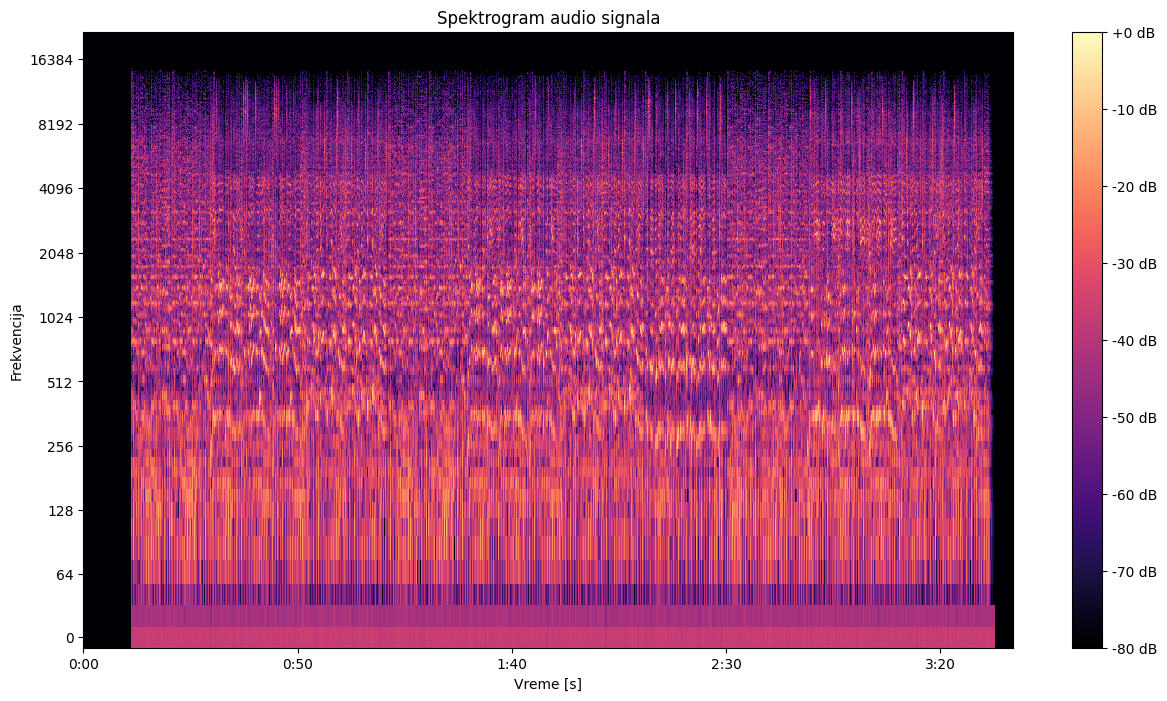

In [9]:
plt.figure(figsize=(15, 8))
librosa.display.specshow(
    spectogram_db,
    sr=sr,
    hop_length=hop_length,
    y_axis='log',
    x_axis='time'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Spektrogram audio signala")
plt.xlabel("Vreme [s]")
plt.ylabel("Frekvencija")
plt.show()

### Učitavanje Demucs modela

In [10]:
model = get_model(name='htdemucs')
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

print(f'Demucs model je učitan: {device}')

Demucs model je učitan: cpu


### Učitavanje audio fajla za podelu na instrumente

In [11]:
wav, sr = librosa.load(path=audio_path, sr=44100, mono=False)

if wav.ndim == 1:
    wav = np.stack([wav, wav])

wav = torch.tensor(wav, dtype=torch.float32)
wav = wav.to(device)

wav = wav.unsqueeze(0)

### Podela instrumenata

In [12]:
output_root = './separated'
os.makedirs(output_root, exist_ok=True)

file_name = os.path.splitext(os.path.basename(audio_path))[0]

song_folder = os.path.join(output_root, file_name)
os.makedirs(song_folder, exist_ok=True)

print(f'{song_folder} folder je kreiran.')

start_time = time.time()
with torch.no_grad():
    sources = apply_model(model, wav)
finish_time = time.time() - start_time

print(f'[{round(finish_time, 2)}s]: Podela na instrumente je završena.')

sources = sources[0]
source_names = ['drums', 'bass', 'other', 'vocals']

separated = {}

for i, name in enumerate(source_names):
    audio = sources[i].cpu().numpy()

    audio = np.transpose(audio)

    path = os.path.join(song_folder, f'{file_name}_{name}.wav')
    sf.write(path, audio, sr)

    separated[name] = audio

    print(f'Sačuvano: {path}')

./separated\minela_ti_propadas folder je kreiran.
[148.72s]: Podela na instrumente je završena.
Sačuvano: ./separated\minela_ti_propadas\minela_ti_propadas_drums.wav
Sačuvano: ./separated\minela_ti_propadas\minela_ti_propadas_bass.wav
Sačuvano: ./separated\minela_ti_propadas\minela_ti_propadas_other.wav
Sačuvano: ./separated\minela_ti_propadas\minela_ti_propadas_vocals.wav


### HPSS (Harmonics-Percussive Source Separation) korišćenjem biblioteke librosa

In [13]:
start_time = time.time()
harmonic_signal, percussive_signal = librosa.effects.hpss(signal)
finish_time = time.time() - start_time

print(f'[{round(finish_time, 2)}s]: HPSS podela je završena.')

harmonic_signal = harmonic_signal / np.max(np.abs(harmonic_signal)) # normalizacija harmonic signala
percussive_signal = percussive_signal / np.max(np.abs(percussive_signal)) # normalizacija percussive signala

[32.15s]: HPSS podela je završena.


### Vizuelizacija HPSS komponenti

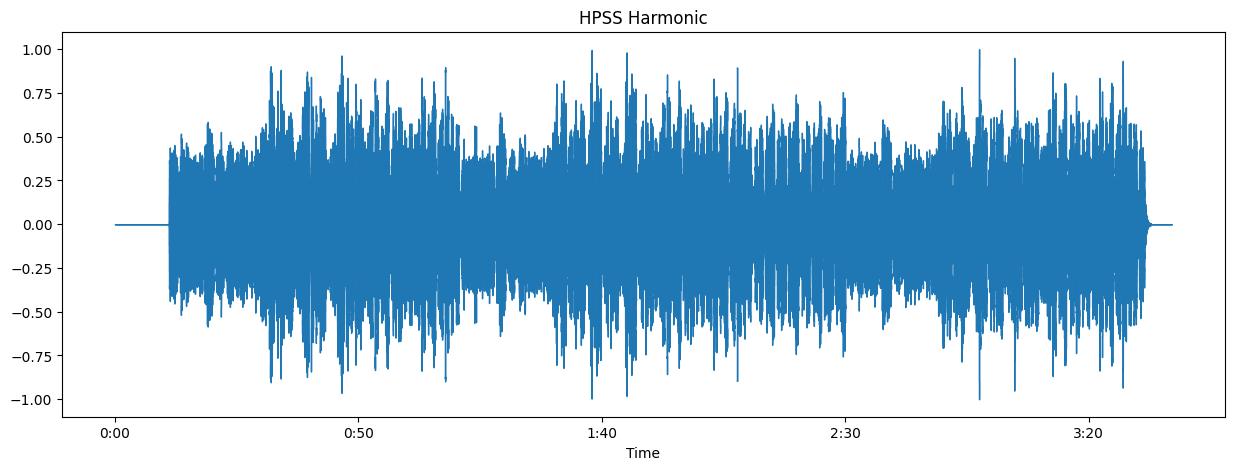

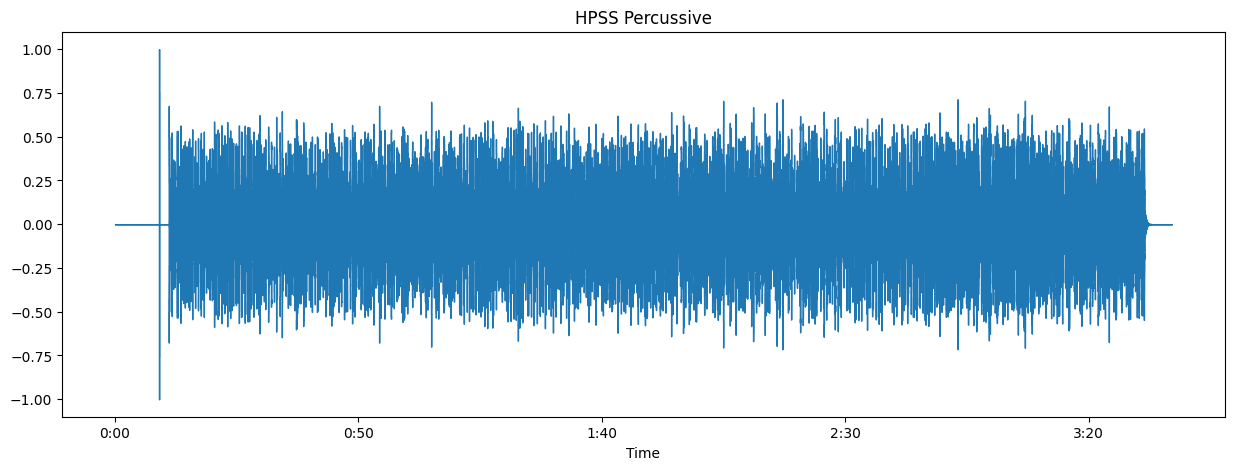

In [14]:
plt.figure(figsize=(15, 5))
librosa.display.waveshow(harmonic_signal, sr=sr)
plt.title('HPSS Harmonic')
plt.show()

plt.figure(figsize=(15, 5))
librosa.display.waveshow(percussive_signal, sr=sr)
plt.title('HPSS Percussive')
plt.show()

### Detekcija Onset-a na celoj pesmi i na izolovanim bubnjevima

In [15]:
drums_signal = separated['drums']

drums_signal = np.mean(drums_signal, axis=1)

drums_signal = drums_signal / np.max(np.abs(drums_signal)) # normalizacija drums signala

In [16]:
onset_env_song = librosa.onset.onset_strength(      # onset na celoj pesmi
    y=signal,
    sr=sr
)

onset_env_drums = librosa.onset.onset_strength(     # onset na izolovanim bubnjevima
    y=drums_signal,
    sr=sr
)

onset_env_hpss = librosa.onset.onset_strength(     # onset na HPSS percussive
    y=percussive_signal,
    sr=sr
)

Nakon što librosa interno uradi STFT, meri se koliko se spektar promenio između frame-ova. Iz toga se dobija niz vrednosti, te ukoliko je vrednost velika, to predstavlja veliku promenu energije, dok mala vrednost predstavlja stabilan signal.

*Onset strength envelope* prikazuje gde se dešavaju ritmički udarci.

### Detekcija BPM-a

Librosa ovde analizira periodičnost onset-a, pronalazi dominantni tempo i određuje poziciju beat-ova.

**Potencijalni problem:** Half-time ili Double-time

Ovaj problem nastaje jer se periodicnost može detektovati na više nivoa. Na primer, može se desiti da je tempo pesme 70bpm, a da algoritam vrati 140bpm ili obrnuto. Ovaj problem ćemo kasnije rešiti detekcijom tempa iz izolovanih perkusija.

In [17]:
tempo_song, beat_frames_song = librosa.beat.beat_track(
    onset_envelope=onset_env_song,
    sr=sr
)

tempo_drums, beat_frames_drums = librosa.beat.beat_track(
    onset_envelope=onset_env_drums,
    sr=sr
)

tempo_hpss, beat_frames_hpss = librosa.beat.beat_track(
    onset_envelope=onset_env_hpss,
    sr=sr
)

tempo_song = round(tempo_song[0], 2)
tempo_drums = round(tempo_drums[0], 2)
tempo_hpss = round(tempo_hpss[0], 2)

data = {'Detected on:': ['Song', 'Isolated drums', 'HPSS percussive'],
        'BPM:': [tempo_song, tempo_drums, tempo_hpss]}

bpm_df = pd.DataFrame(data)
bpm_df

,Detected on:,BPM:
0,Song,99.38
1,Isolated drums,99.38
2,HPSS percussive,99.38


U nastavku će biti korišćen **BPM detektovan na bubnjevima**, jer se smatra pouzdanijim (iako je često isti i za celu pesmu i za izolovane bubnjeve)

### Konverzija Frame-ova u vreme

In [18]:
beat_times = librosa.frames_to_time(
    beat_frames_drums,
    sr=sr
)

### Prikaz waveform-a sa BPM-om

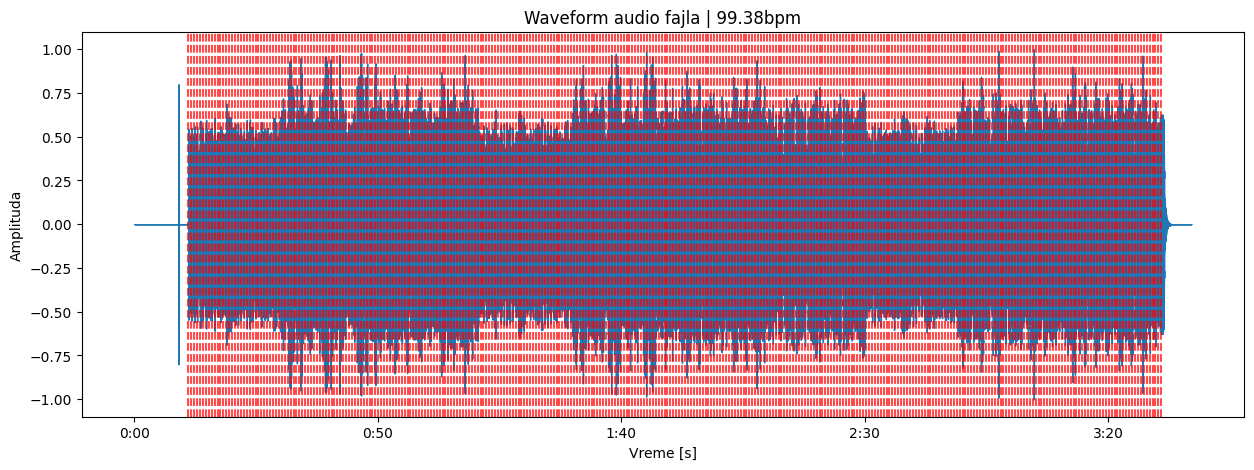

In [19]:
plt.figure(figsize=(15, 5))
librosa.display.waveshow(
    signal,
    sr=sr
)

for beat in beat_times:
    plt.axvline(
        x=beat,
        color='red',
        linestyle='--',
        alpha=0.7
    )

plt.title(f'Waveform audio fajla | {round(float(tempo_drums), 2)}bpm')
plt.xlabel('Vreme [s]')
plt.ylabel('Amplituda')
plt.show()

### Chroma feature extraction

**Chroma** predstavlja energiju svih nota nezavisno od oktava.



In [20]:
instruments_signal = separated['other']

instruments_signal = np.mean(instruments_signal, axis=1)

instruments_signal = instruments_signal / np.max(np.abs(instruments_signal))

In [21]:
chroma_song = librosa.feature.chroma_stft(
    y=signal,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length
)

chroma_instruments = librosa.feature.chroma_stft(
    y=instruments_signal,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length
)

chroma_harmonic_hpss = librosa.feature.chroma_stft(
    y=harmonic_signal,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length
)

print(f'Chroma shape (SONG): {chroma_song.shape}')
print(f'Chroma shape (ISOLATED INSTRUMENTS): {chroma_instruments.shape}')
print(f'Chroma shape (HARMONIC HPSS): {chroma_harmonic_hpss.shape}')

Chroma shape (SONG): (12, 18697)
Chroma shape (ISOLATED INSTRUMENTS): (12, 18697)
Chroma shape (HARMONIC HPSS): (12, 18697)


### Prikaz chroma feature-a za celu pesmu i za izolovane instrumente

In [22]:
def show_chroma_features(chroma, title):
    plt.figure(figsize=(15, 6))

    librosa.display.specshow(
        chroma,
        x_axis='time',
        y_axis=None,
        hop_length=hop_length,
        cmap='coolwarm'
    )

    plt.yticks(
        np.arange(12),
        ['C', 'C#', 'D', 'D#', 'E', 'F',
         'F#', 'G', 'G#', 'A', 'A#', 'B']
    ) # na y-osi smo ovako predstavili note, zato što se bez toga prikazuju samo note u C maj

    plt.colorbar()
    plt.title(title)
    plt.xlabel('Vreme [s]')
    plt.ylabel('Nota')
    plt.show()

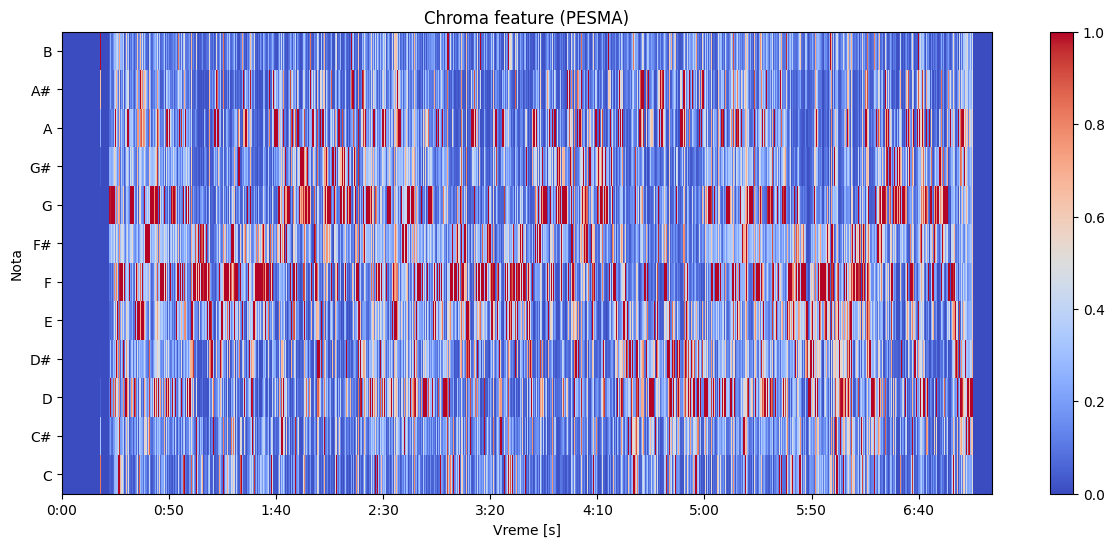

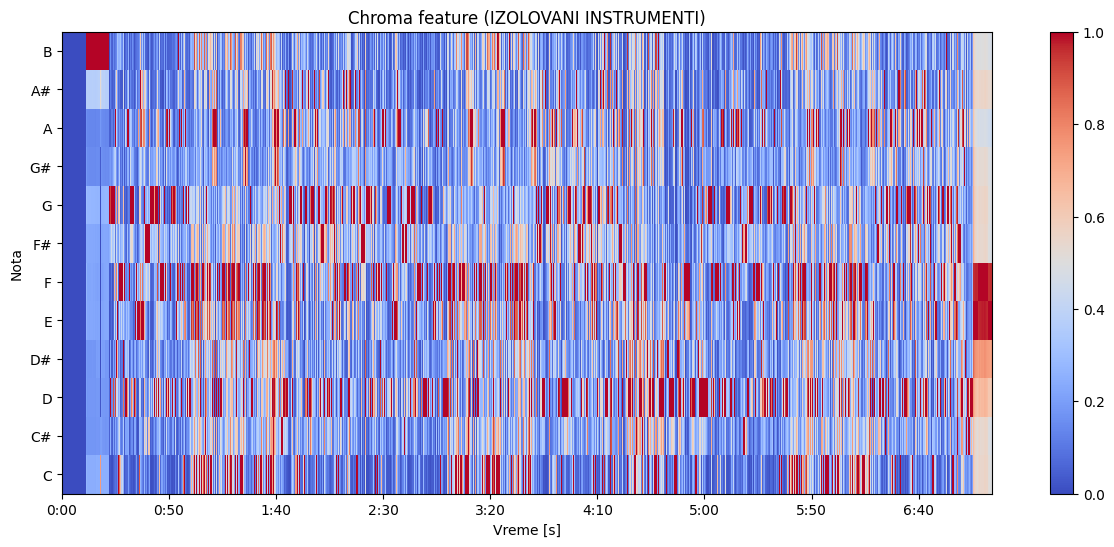

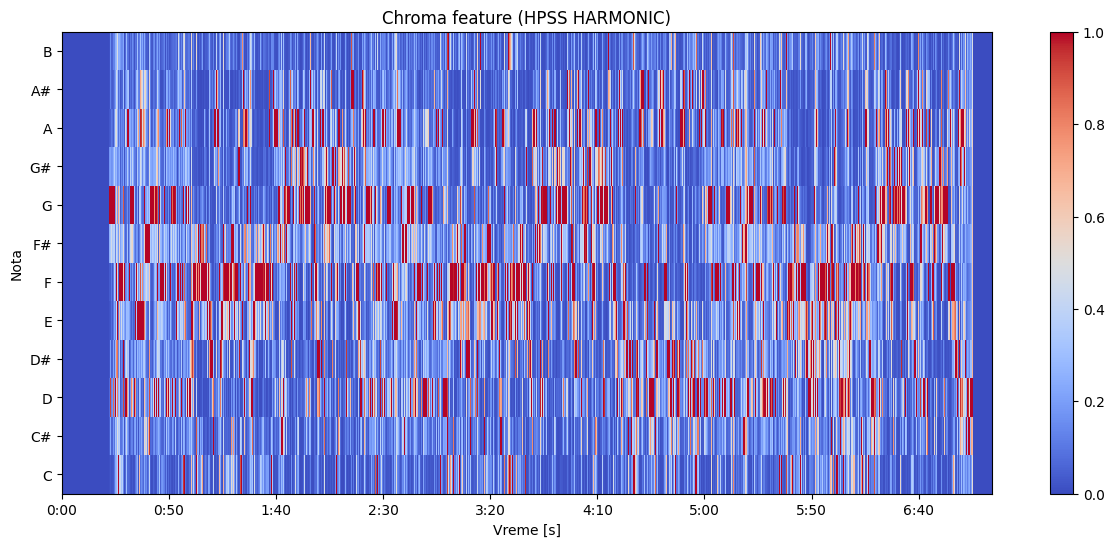

In [23]:
show_chroma_features(chroma_song, 'Chroma feature (PESMA)')
show_chroma_features(chroma_instruments, 'Chroma feature (IZOLOVANI INSTRUMENTI)')
show_chroma_features(chroma_harmonic_hpss, 'Chroma feature (HPSS HARMONIC)')

### Prikaz prosečne energije svake note na celoj pesmi i na izolovanim instrumentima

In [24]:
notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

chroma_song_mean = np.mean(chroma_song, axis=1)
chroma_instruments_mean = np.mean(chroma_instruments, axis=1)
chroma_harmonic_hpss_mean = np.mean(chroma_harmonic_hpss, axis=1)

In [25]:
def show_average_notes_energy(chroma, title):

    plt.figure(figsize=(12, 5))

    bars = plt.bar(notes, chroma)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            x=bar.get_x() + bar.get_width() / 2,
            y=height,
            s=f'{height:.3f}',
            ha='center',
            va='bottom'
        )

    plt.title(title)
    plt.xlabel('Note')
    plt.ylabel('Energija')

    plt.show()

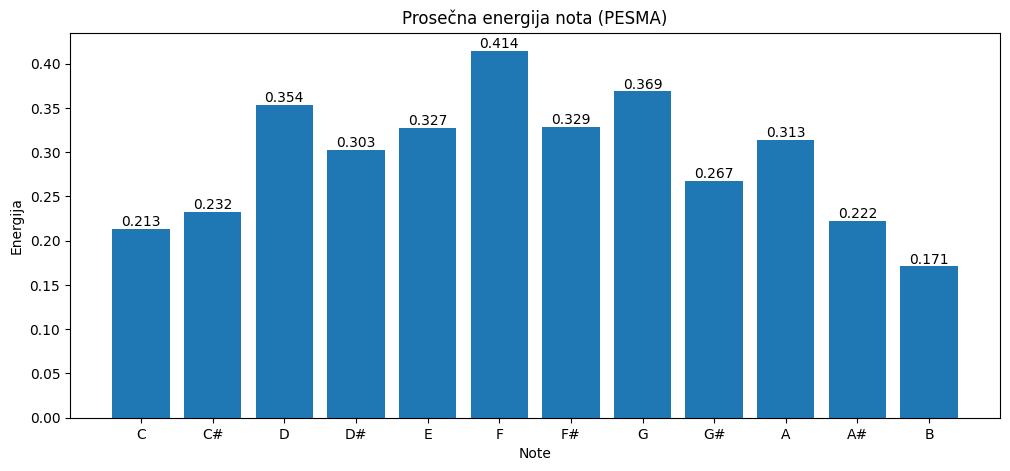

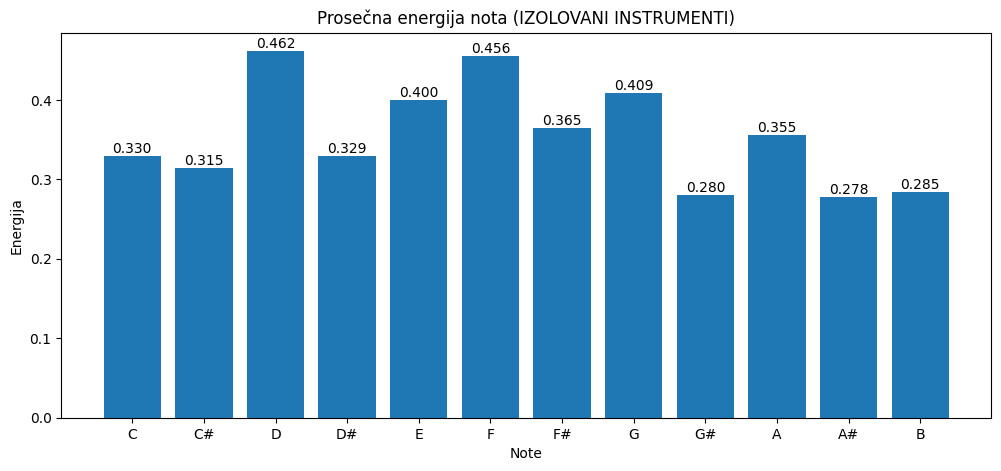

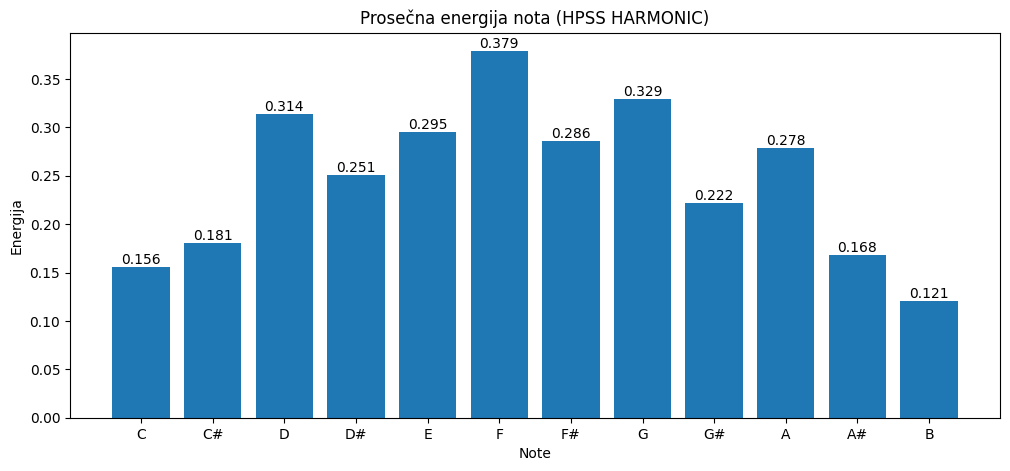

In [26]:
show_average_notes_energy(chroma_song_mean, 'Prosečna energija nota (PESMA)')
show_average_notes_energy(chroma_instruments_mean, 'Prosečna energija nota (IZOLOVANI INSTRUMENTI)')
show_average_notes_energy(chroma_harmonic_hpss_mean, 'Prosečna energija nota (HPSS HARMONIC)')

Razlika između prosečnih energija noti je jasnija kod izolovanih instrumenata, što dovodi mnogo bržeg, jednostavnijeg i očiglednijeg određivanja tonaliteta.

U nastavku će biti korišćene prosečne note za sve slučajeve kako bi se uporedili dobijeni rezultati za rezultat.

### Krumhansl-Schmuckler (K-S) profili

**K-S algoritam** predstalvja najpoznatiji algoritam za pronalaženje tonaliteta.

**K-S profili** predstavljaju statističke modele, tačnije "tipične važnosti" svake note u major i minor tonalitetu.

In [27]:
major_profile = np.array([
    6.35, 2.23, 3.48, 2.33,
    4.38, 4.09, 2.52, 5.19,
    2.39, 3.66, 2.29, 2.88
])

minor_profile = np.array([
    6.33, 2.68, 3.52, 5.38,
    2.60, 3.53, 2.54, 4.75,
    3.98, 2.69, 3.34, 3.17
])

### Funkcija za izbor najboljeg tonaliteta

In [28]:
def detect_key(chroma_mean):

    major_scores = []
    minor_scores = []

    for i in range(12):
        rotated_major = np.roll(major_profile, i)
        rotated_minor = np.roll(minor_profile, i)

        major_corr = np.corrcoef(
            chroma_mean,
            rotated_major
        )[0, 1]

        minor_corr = np.corrcoef(
            chroma_mean,
            rotated_minor
        )[0, 1]

        major_scores.append(major_corr)
        minor_scores.append(minor_corr)

    best_major = np.argmax(major_scores)
    best_minor = np.argmax(minor_scores)

    major_score = major_scores[best_major]
    minor_score = minor_scores[best_minor]

    if major_score > minor_score:
        detected_key = f"{notes[best_major]} Major"
        confidence = major_score
    else:
        detected_key = f"{notes[best_minor]} Minor"
        confidence = minor_score

    return detected_key, confidence, major_scores, minor_scores

### Izbor najboljeg tonaliteta na celoj pesmi, na izolovanim instrumentima i na HPSS harmonic

In [29]:
song_key, song_conf, song_major_scores, song_minor_scores = detect_key(chroma_song_mean)
demucs_key, demucs_conf, demucs_major_scores, demucs_minor_scores = detect_key(chroma_instruments_mean)
hpss_key, hpss_conf, hpss_major_scores, hpss_minor_scores = detect_key(chroma_harmonic_hpss_mean)

### Prikaz dobijenih rezultata za tonalitet sa njihovim sigurnošćima

In [30]:
def visualize_correlation_between_notes(major_scores, minor_scores, title):
    plt.figure(figsize=(14, 5))

    plt.plot(notes, major_scores, label='Major')
    plt.plot(notes, minor_scores, label='Minor')

    plt.title(f'Korelacija tonaliteta | {title}')
    plt.xlabel('Tonalitet')
    plt.ylabel('Korelacija')

    plt.legend()
    plt.grid()

    plt.show()

### Vizualizacija korelacija na celoj pesmi, na izolovanim instrumentima i na HPSS harmonic

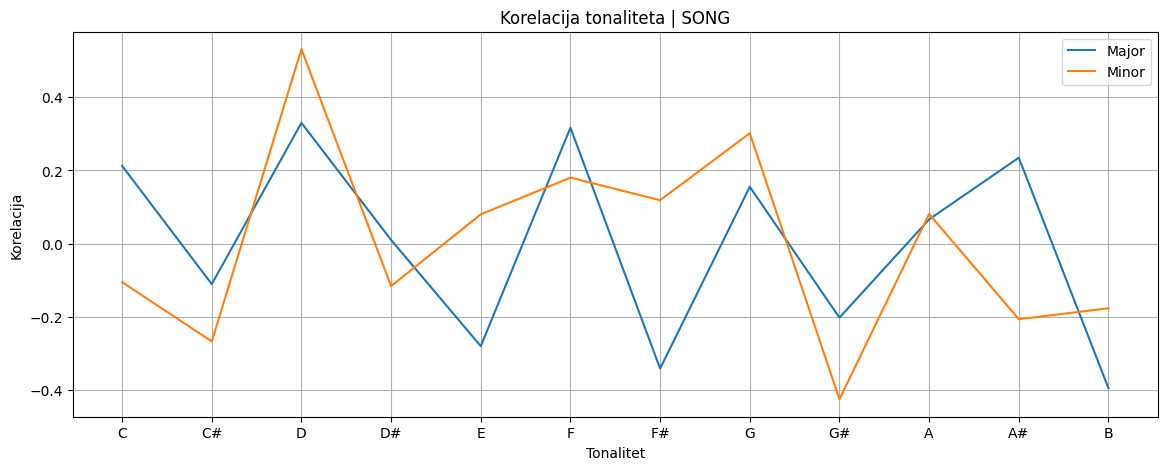

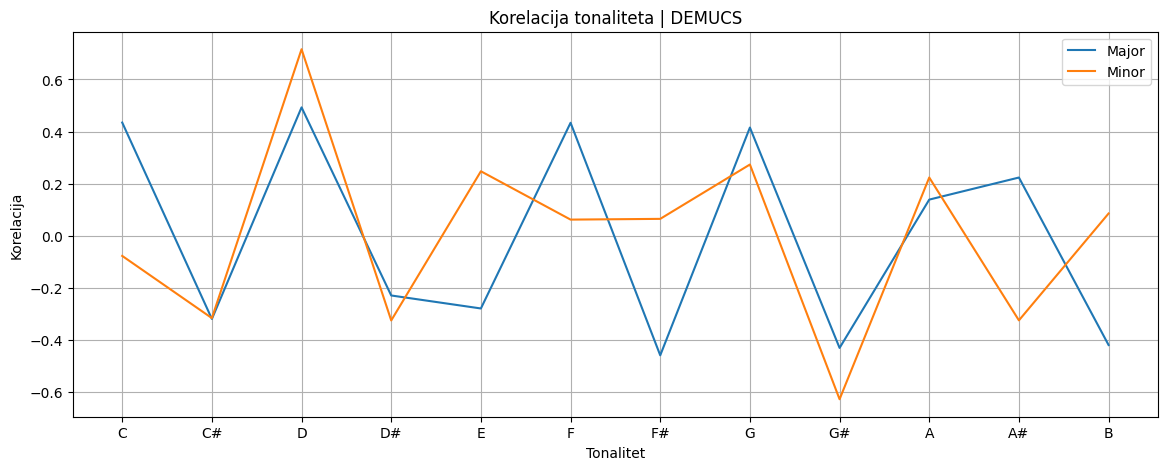

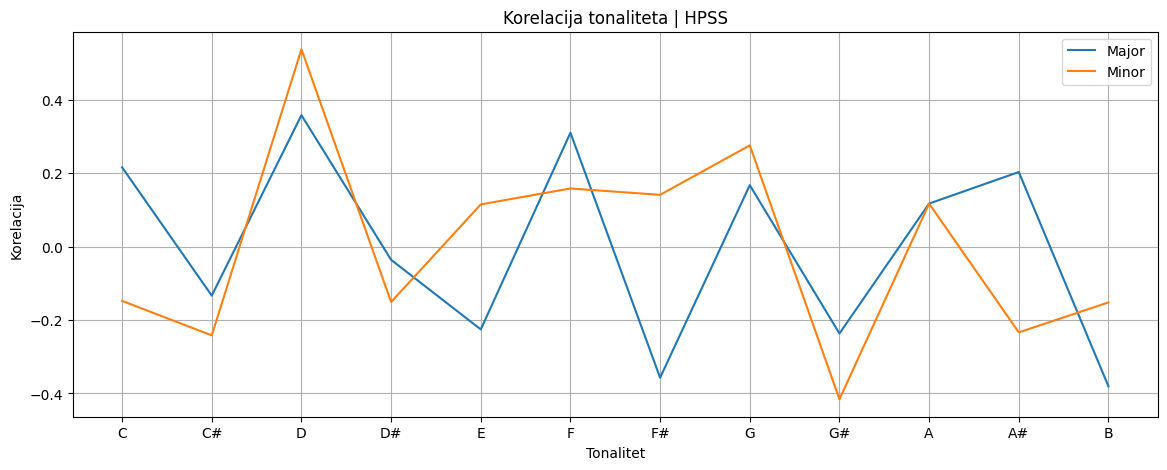

In [31]:
visualize_correlation_between_notes(song_major_scores, song_minor_scores, 'SONG')
visualize_correlation_between_notes(demucs_major_scores, demucs_minor_scores, 'DEMUCS')
visualize_correlation_between_notes(hpss_major_scores, hpss_minor_scores, 'HPSS')

### Prikaz dobijenih rezultata za detektovani tonalitet

In [32]:
data = {
    'Detected on:': ['Song', 'Isolated instruments (Demucs)', 'HPSS Harmonic'],
    'Detected key:': [song_key, demucs_key, hpss_key],
    'Confidence:': [song_conf, demucs_conf, hpss_conf]
}
key_df = pd.DataFrame(data)
key_df

,Detected on:,Detected key:,Confidence:
0,Song,D Minor,0.530564
1,Isolated instruments (Demucs),D Minor,0.716058
2,HPSS Harmonic,D Minor,0.537295


Na osnovu dobijenih rezultata možemo zaključiti da detektovani tonalitet sa najvećim poverenjem ima Isolated instruments.